In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("fuzzy_sambal_dataset.csv")
df.head()

,Cabai_g,Tomat_g,Minyak_ml,Spiciness,RecommendedSaltGram
0,7.6,6.9,22.6,20.0,1.4
1,78.0,35.7,1.8,90.0,2.8
2,43.8,81.3,22.3,20.0,1.4
3,72.3,42.8,28.4,20.0,1.4
4,97.8,60.0,18.1,20.0,1.4


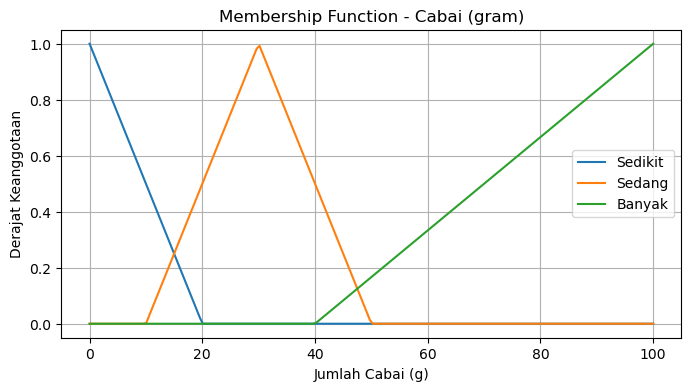

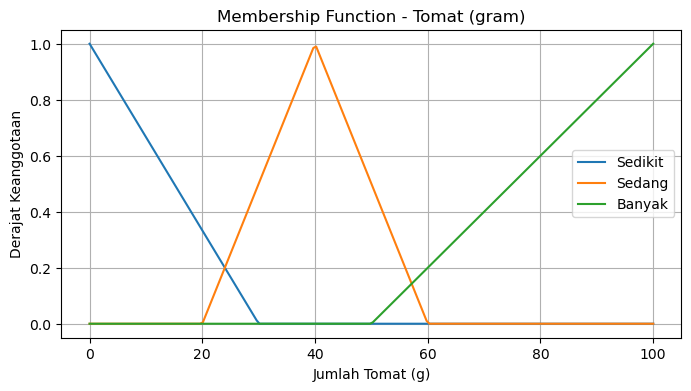

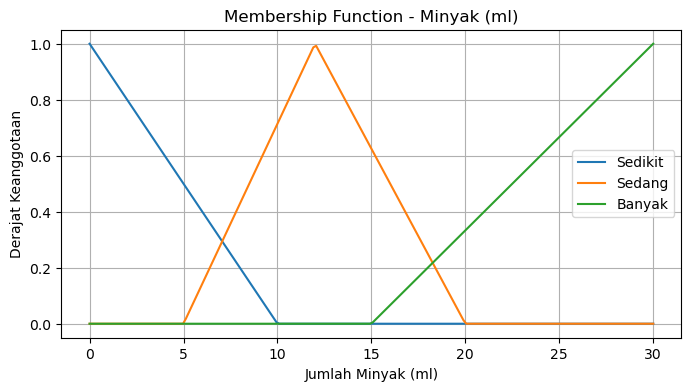

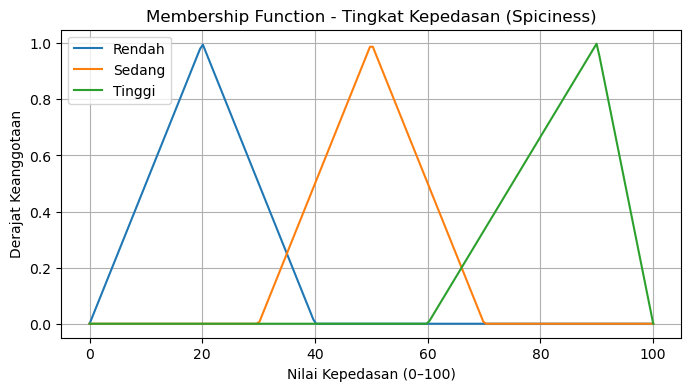

In [14]:
# Fungsi Triangular Membership
def tri(x, a, b, c):
    x = np.array(x, dtype=float)
    y = np.zeros_like(x)
    y[(x >= a) & (x <= b)] = (x[(x >= a) & (x <= b)] - a) / (b - a + 1e-9)
    y[(x > b) & (x <= c)] = (c - x[(x > b) & (x <= c)]) / (c - b + 1e-9)
    y[x == b] = 1
    return np.clip(y, 0, 1)
x_cabai = np.linspace(0, 100, 200)
x_tomat = np.linspace(0, 100, 200)
x_minyak = np.linspace(0, 30, 200)
x_spicy = np.linspace(0, 100, 200)

# Cabai
plt.figure(figsize=(8,4))
plt.plot(x_cabai, tri(x_cabai, 0, 0, 20), label="Sedikit")
plt.plot(x_cabai, tri(x_cabai, 10, 30, 50), label="Sedang")
plt.plot(x_cabai, tri(x_cabai, 40, 100, 100), label="Banyak")
plt.title("Membership Function - Cabai (gram)")
plt.xlabel("Jumlah Cabai (g)")
plt.ylabel("Derajat Keanggotaan")
plt.legend()
plt.grid(True)
plt.show()

# Tomat
plt.figure(figsize=(8,4))
plt.plot(x_tomat, tri(x_tomat, 0, 0, 30), label="Sedikit")
plt.plot(x_tomat, tri(x_tomat, 20, 40, 60), label="Sedang")
plt.plot(x_tomat, tri(x_tomat, 50, 100, 100), label="Banyak")
plt.title("Membership Function - Tomat (gram)")
plt.xlabel("Jumlah Tomat (g)")
plt.ylabel("Derajat Keanggotaan")
plt.legend()
plt.grid(True)
plt.show()

# Minyak
plt.figure(figsize=(8,4))
plt.plot(x_minyak, tri(x_minyak, 0, 0, 10), label="Sedikit")
plt.plot(x_minyak, tri(x_minyak, 5, 12, 20), label="Sedang")
plt.plot(x_minyak, tri(x_minyak, 15, 30, 30), label="Banyak")
plt.title("Membership Function - Minyak (ml)")
plt.xlabel("Jumlah Minyak (ml)")
plt.ylabel("Derajat Keanggotaan")
plt.legend()
plt.grid(True)
plt.show()

# Output Spiciness
plt.figure(figsize=(8,4))
plt.plot(x_spicy, tri(x_spicy, 0, 20, 40), label="Rendah")
plt.plot(x_spicy, tri(x_spicy, 30, 50, 70), label="Sedang")
plt.plot(x_spicy, tri(x_spicy, 60, 90, 100), label="Tinggi")
plt.title("Membership Function - Tingkat Kepedasan (Spiciness)")
plt.xlabel("Nilai Kepedasan (0–100)")
plt.ylabel("Derajat Keanggotaan")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# Insight baru
df["EstimatedCustomerPreference"] = (
    100 
    - abs(df["Spiciness"] - 50) * 0.8   
    + (50 - abs(df["Tomat_g"] - 50)) * 0.1  
    - (df["Minyak_ml"] - 15).abs() * 0.3
).clip(0, 100).round(2)

# Tampilkan 10 baris pertama
df.head(10)

,Cabai_g,Tomat_g,Minyak_ml,Spiciness,RecommendedSaltGram,EstimatedCustomerPreference
0,7.6,6.9,22.6,20.00,1.40,74.41
1,78.0,35.7,1.8,90.00,2.80,67.61
2,43.8,81.3,22.3,20.00,1.40,75.68
3,72.3,42.8,28.4,20.00,1.40,76.26
4,97.8,60.0,18.1,20.00,1.40,79.07
5,53.8,72.8,8.6,36.44,1.73,89.95
6,50.1,82.1,20.2,20.00,1.40,76.23
7,7.2,76.1,21.4,20.00,1.40,76.47
8,26.8,0.7,19.7,20.00,1.40,74.66
9,50.0,42.0,4.4,90.00,2.80,69.02


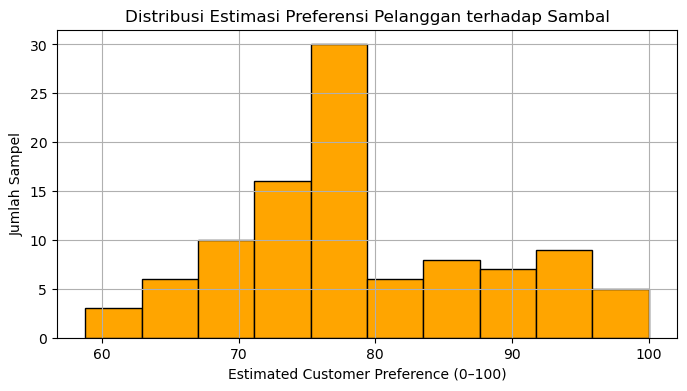

In [21]:
import matplotlib.pyplot as plt

# Plot distribusi insight baru (EstimatedCustomerPreference)
plt.figure(figsize=(8, 4))
plt.hist(df["EstimatedCustomerPreference"], bins=10, color="orange", edgecolor="black")
plt.title("Distribusi Estimasi Preferensi Pelanggan terhadap Sambal")
plt.xlabel("Estimated Customer Preference (0–100)")
plt.ylabel("Jumlah Sampel")
plt.grid(True)
plt.show()

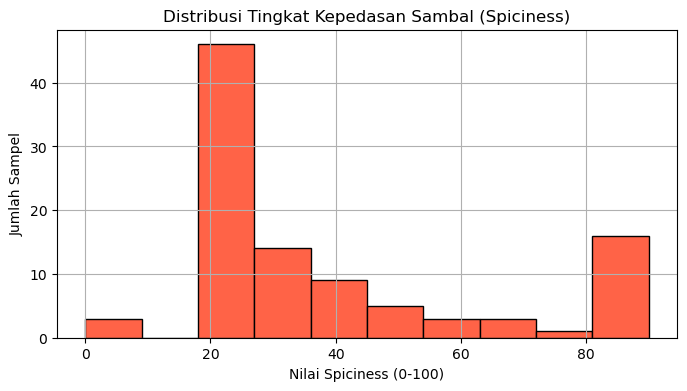

In [22]:
plt.figure(figsize=(8,4))
plt.hist(df["Spiciness"], bins=10, color="tomato", edgecolor="black")
plt.title("Distribusi Tingkat Kepedasan Sambal (Spiciness)")
plt.xlabel("Nilai Spiciness (0-100)")
plt.ylabel("Jumlah Sampel")
plt.grid(True)
plt.show()